# Olist E-Commerce Analysis

## Business context
An analyst at Olist wants to understand two things: (1) where revenue is 
concentrated geographically and what drives it, and (2) how delivery performance 
affects customer satisfaction. This analysis identifies which states, sellers, 
or categories warrant operational focus and what specifically improves the 
customer experience.

## Questions
1. Where is revenue concentrated, and what does the top tier look like?
2. Does faster delivery actually correlate with better reviews?

## Tools
- Python 3.12, pandas, numpy
- matplotlib, seaborn
- (Optional) SQLite via sqlite3 for SQL practice

## Status
In progress — exploratory phase.

## 1. Data loading
Load all relevant CSVs and inspect basic shape.

In [11]:
import pandas as pd

orders = pd.read_csv('data/olist_orders_dataset.csv')
print(orders.shape)
orders.head()
orders = pd.read_csv('data/olist_orders_dataset.csv')
customers = pd.read_csv('data/olist_customers_dataset.csv')
order_items = pd.read_csv('data/olist_order_items_dataset.csv')
products = pd.read_csv('data/olist_products_dataset.csv')
reviews = pd.read_csv('data/olist_order_reviews_dataset.csv')

print("orders:", orders.shape)
print("customers:", customers.shape)
print("order_items:", order_items.shape)
print("products:", products.shape)
print("reviews:", reviews.shape)

(99441, 8)
orders: (99441, 8)
customers: (99441, 5)
order_items: (112650, 7)
products: (32951, 9)
reviews: (99224, 7)


## 2. Initial inspection
For each table, look at the head and check for nulls.

In [12]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [13]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


## 3. Data cleaning
[To be done: handle nulls, parse dates, drop unused columns]


In [14]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


To compute revenue by state, I need:
- order_items.price + order_items.freight_value (per item)
- joined to orders on order_id
- joined to customers on customer_id (to get state)

In [15]:
print(order_items[['order_id', 'price', 'freight_value']].head())
print(customers[['customer_id', 'customer_state']].head())

                           order_id   price  freight_value
0  00010242fe8c5a6d1ba2dd792cb16214   58.90          13.29
1  00018f77f2f0320c557190d7a144bdd3  239.90          19.93
2  000229ec398224ef6ca0657da4fc703e  199.00          17.87
3  00024acbcdf0a6daa1e931b038114c75   12.99          12.79
4  00042b26cf59d7ce69dfabb4e55b4fd9  199.90          18.14
                        customer_id customer_state
0  06b8999e2fba1a1fbc88172c00ba8bc7             SP
1  18955e83d337fd6b2def6b18a428ac77             SP
2  4e7b3e00288586ebd08712fdd0374a03             SP
3  b2b6027bc5c5109e529d4dc6358b12c3             SP
4  4f2d8ab171c80ec8364f7c12e35b23ad             SP


In [16]:
# Start with order_items (one row per item)
df = order_items.merge(orders[['order_id', 'customer_id', 'order_status']], on='order_id', how='left')

# Add customer state
df = df.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')

# Filter to delivered orders only — incomplete orders shouldn't count for revenue
df = df[df['order_status'] == 'delivered']

# Compute total revenue per item (price + shipping)
df['item_revenue'] = df['price'] + df['freight_value']

print(df.shape)
df.head()

(110197, 11)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,customer_state,item_revenue
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,RJ,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,SP,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,MG,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,SP,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,SP,218.04


In [17]:
revenue_by_state = df.groupby('customer_state').agg(
    total_revenue=('item_revenue', 'sum'),
    order_count=('order_id', 'nunique'),
    item_count=('order_id', 'count')
).reset_index()

revenue_by_state['avg_order_value'] = revenue_by_state['total_revenue'] / revenue_by_state['order_count']
revenue_by_state = revenue_by_state.sort_values('total_revenue', ascending=False)

revenue_by_state.head(10)

,customer_state,total_revenue,order_count,item_count,avg_order_value
25,SP,5769703.15,40501,46448,142.458289
18,RJ,2055401.57,12350,14143,166.429277
10,MG,1818891.67,11354,12916,160.198315
22,RS,861472.79,5345,6134,161.173581
17,PR,781708.80,4923,5649,158.787081
23,SC,595127.78,3546,4097,167.830733
4,BA,591137.81,3256,3683,181.553381
6,DF,346123.35,2080,2355,166.405457
8,GO,334212.35,1957,2277,170.777900
7,ES,317657.93,1995,2225,159.227033


### Visualization
Bar chart of the top 10 states by total revenue.

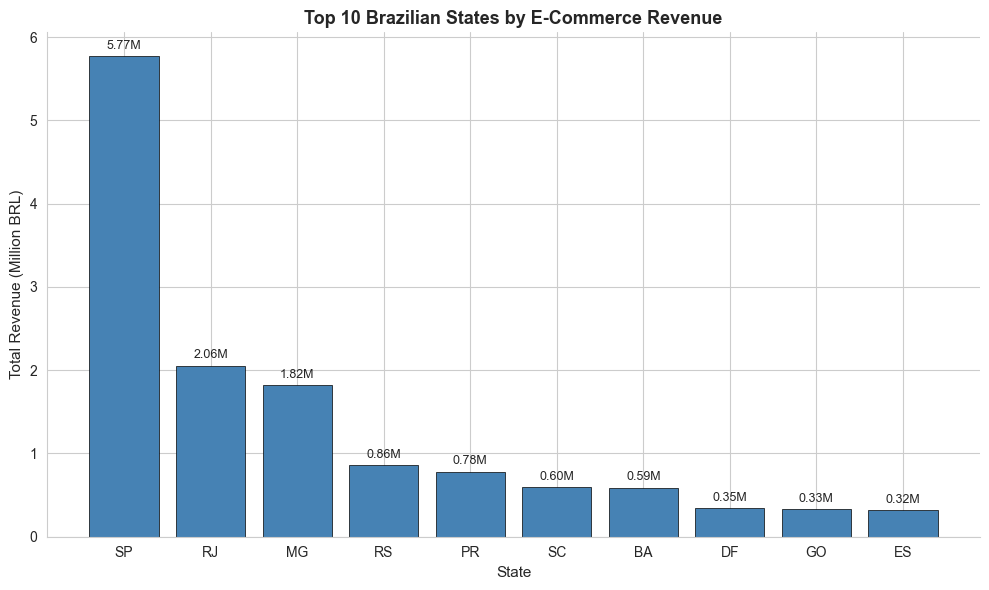

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style settings (do once at top of notebook, but fine here for now)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Take top 10
top_10 = revenue_by_state.head(10)

# Create the chart
fig, ax = plt.subplots()
bars = ax.bar(top_10['customer_state'], top_10['total_revenue'] / 1_000_000, 
              color='steelblue', edgecolor='black', linewidth=0.5)

# Labels and title
ax.set_xlabel('State', fontsize=11)
ax.set_ylabel('Total Revenue (Million BRL)', fontsize=11)
ax.set_title('Top 10 Brazilian States by E-Commerce Revenue', fontsize=13, fontweight='bold')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.05,
            f'{height:.2f}M', ha='center', va='bottom', fontsize=9)

# Clean up
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Average order value by state
The top revenue state (SP) has the lowest average order value in the top 10. 
Revenue concentration is driven by order volume, not basket size.

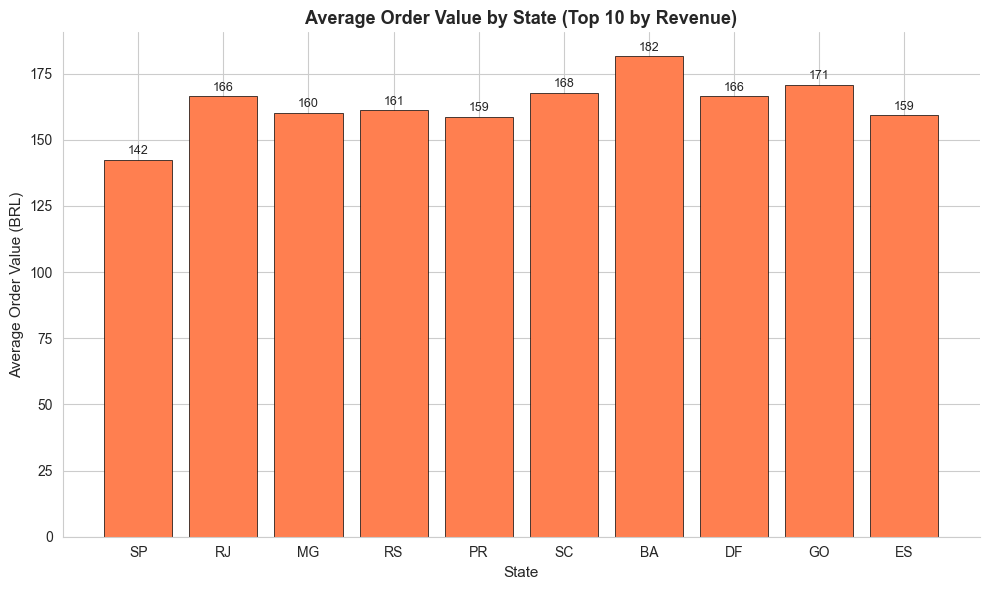

In [19]:
# Same top 10, different metric
fig, ax = plt.subplots()
bars = ax.bar(top_10['customer_state'], top_10['avg_order_value'],
              color='coral', edgecolor='black', linewidth=0.5)

ax.set_xlabel('State', fontsize=11)
ax.set_ylabel('Average Order Value (BRL)', fontsize=11)
ax.set_title('Average Order Value by State (Top 10 by Revenue)', fontsize=13, fontweight='bold')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 1,
            f'{height:.0f}', ha='center', va='bottom', fontsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Findings: Question 1 - Revenue concentration

**Revenue is heavily concentrated in the southeastern states.** São Paulo (SP) 
alone generates R$5.77M in revenue from delivered orders, more than the next 
three states combined. The top three states (SP, RJ, MG) account for roughly 
77% of revenue across the top 10 states.

**Concentration is driven by order volume, not basket size.** Despite 
generating the most revenue, São Paulo has the *lowest* average order value 
(R$142) among the top 10 states. States like Bahia (R$182), Goiás (R$171), 
and Santa Catarina (R$168) have notably higher AOVs but a tiny fraction of 
SP's order volume.

**Business implication.** Operations and marketing investment should be 
weighted toward the southeastern volume markets (SP, RJ, MG), but pricing 
or upsell strategy could be tested in the higher-AOV markets where customers 
already place larger orders. The volume markets are unlikely to respond to 
basket-size optimization in the same way.

### Caveats
- Analysis filters to delivered orders only; cancelled and incomplete orders are excluded.
- "Order count" here is the number of unique orders. Revenue includes both product price and freight.
- This analysis does not yet break down which categories drive revenue within top states; that follows in the next section.

## 4. Question 1: Revenue concentration
[To be done: revenue by state, top categories within top states, AOV]

## 5. Question 2: Delivery and reviews
[To be done: compute delivery times, correlate with review scores]

## 6. Findings and recommendations
[To be written at the end]